Cleaned Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

All required columns are available.

First 5 rows:
          Country  Quantity  UnitPrice  TotalAmount
0  United Kingdom         6       2.55        15.30
1  United Kingdom         6       3.39        20.34
2  United Kingdom         8       2.75        22.00
3  United Kingdom         6       3.39        20.34
4  United Kingdom         6       3.39        20.34

Top 10 Countries by Revenue:
Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: TotalAmount, dtype: float64


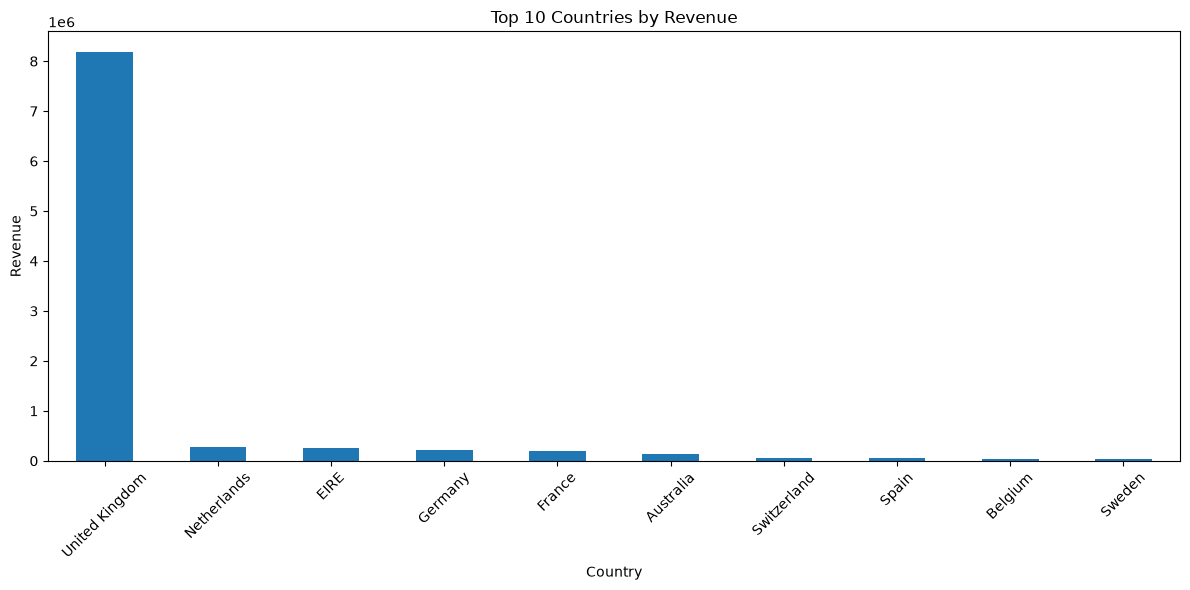

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


# STEP 1: LOAD THE EXCEL FILE

df = pd.read_excel(
    r"D:\Users\Junaid\Desktop\Week 2\Data\Ecommerce_Sales_Data.csv.xlsx"
)

# STEP 2: CLEAN COLUMN NAMES

# Remove extra spaces and quote marks from column names
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.replace("'", "", regex=False)
    .str.replace('"', "", regex=False)
)

# Display cleaned column names
print("Cleaned Column Names:")
print(df.columns.tolist())

# --------------------------------------------------
# STEP 3: CHECK REQUIRED COLUMNS
# --------------------------------------------------

required_columns = [
    "Country",
    "Quantity",
    "UnitPrice"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("\nMissing columns:", missing_columns)
else:
    print("\nAll required columns are available.")

# --------------------------------------------------
# STEP 4: CONVERT NUMERIC COLUMNS
# --------------------------------------------------

df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)

df["UnitPrice"] = pd.to_numeric(
    df["UnitPrice"],
    errors="coerce"
)

# --------------------------------------------------
# STEP 5: CREATE TOTAL AMOUNT
# --------------------------------------------------

df["TotalAmount"] = (
    df["Quantity"] * df["UnitPrice"]
)

# --------------------------------------------------
# STEP 6: CHECK THE NEW COLUMN
# --------------------------------------------------

print("\nFirst 5 rows:")
print(
    df[
        [
            "Country",
            "Quantity",
            "UnitPrice",
            "TotalAmount"
        ]
    ].head()
)

# --------------------------------------------------
# STEP 7: CALCULATE REVENUE BY COUNTRY
# --------------------------------------------------

country_revenue = (
    df.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Countries by Revenue:")
print(country_revenue)

# --------------------------------------------------
# STEP 8: CREATE THE CHART
# --------------------------------------------------

plt.figure(figsize=(12, 6))

country_revenue.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

# --------------------------------------------------
# STEP 9: SAVE THE CHART
# --------------------------------------------------

os.makedirs("../outputs", exist_ok=True)

plt.savefig(
    "../outputs/top_10_countries_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

# Display chart
plt.show()